In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


In [3]:
df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/usuario_202603050949_limpo.csv")

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_df.to_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/train_users_dataset.csv", index=False)
test_df.to_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/test_users_dataset.csv", index=False)

/tmp/ipykernel_17786/278177682.py:1: DtypeWarning: Columns (0: bo_emitentegta, 1: bo_primeiroacesso) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/usuario_202603050949_limpo.csv")


In [4]:
df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/usuario_202603050949_limpo.csv")
train_df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/train_users_dataset.csv")
test_df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/test_users_dataset.csv")

/tmp/ipykernel_17786/3627366523.py:1: DtypeWarning: Columns (0: bo_emitentegta, 1: bo_primeiroacesso) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/usuario_202603050949_limpo.csv")
/tmp/ipykernel_17786/3627366523.py:2: DtypeWarning: Columns (0: bo_emitentegta, 1: bo_primeiroacesso) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/train_users_dataset.csv")
/tmp/ipykernel_17786/3627366523.py:3: DtypeWarning: Columns (0: bo_primeiroacesso) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv("/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/data/processed/test_users_dataset.csv")


Para preencher dados NaN inválidos do dataset

In [5]:
X = df.drop(columns=["cpf_hash", "id_pessoa"])

imputer = SimpleImputer(strategy="most_frequent")
X_imputed = imputer.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_imputed)

In [6]:
df.isna().sum().sort_values(ascending=False)

X = df.drop(columns=["cpf_hash", "id_pessoa"])

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_imputed)

df.groupby("cluster").mean(numeric_only=True)

,id_pessoa,bo_emitentegtv,email_verificado,bo_veterinario,bo_emitentegtvexterno,bo_classificadorsemente,bo_permissao_cancelamento_gta,nu_tentativas
cluster,,,,,,,,
0,591137.784942,0.000000,0.0,0.00000,0.000000,0.0,0.0,1.000000
1,438021.940815,0.000004,0.0,0.00000,0.000000,0.0,0.0,1.000000
2,457598.690407,0.001933,1.0,0.00037,0.000535,0.0,0.0,1.001933


In [7]:
bool_cols = [
    "bo_emitentegta",
    "bo_emitentegtv",
    "email_verificado",
    "bo_veterinario",
    "bo_emitentegtvexterno",
    "bo_classificadorsemente",
    "bo_permissao_cancelamento_gta",
    "bo_primeiroacesso"
]

In [8]:
imputer = SimpleImputer(strategy="most_frequent")
df_bin = pd.DataFrame(
    imputer.fit_transform(df[bool_cols]),
    columns=bool_cols
).astype(int)

In [9]:
from mlxtend.frequent_patterns import apriori, association_rules

df_bin = df[bool_cols].fillna(False).astype(int)

freq = apriori(df_bin, min_support=0.005, use_colnames=True)
rules = association_rules(freq, metric="confidence", min_threshold=0.5)

rules.sort_values("support", ascending=False).head(10)

/home/enzo-maldinni/Documentos/SIGAMA-data-analysis/src/venv/lib/python3.13/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bo_emitentegta}),frozenset({email_verificado}),0.008886,0.070342,0.008727,0.982096,13.961728,1.0,0.008102,51.925623,0.936699,0.123779,0.980742,0.553078


Usuários com perfil de emissão de GTA apresentam uma taxa de verificação de email significativamente superior ao restante da base, com probabilidade superior a 98% e forte associação estatística (lift ≈ 14).

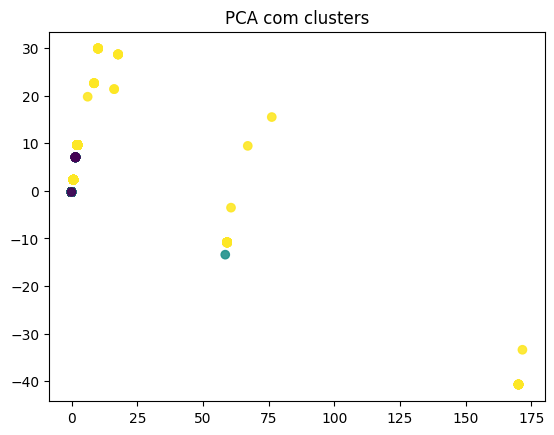

In [10]:

X = df[bool_cols + ["nu_tentativas"]]

# Preencher NaN
imputer = SimpleImputer(strategy="most_frequent")
X = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], alpha=0.9)
plt.title("PCA com clusters")
plt.show()

A projeção em duas dimensões por PCA indica que os dados não são homogêneos, apresentando três regiões distintas.

O grupo à esquerda concentra a maioria dos usuários, com comportamento semelhante e possivelmente baixo nível de engajamento. A região central representa um grupo menor, com maior variabilidade e características intermediárias.

Dois pontos isolados à direita caracterizam outliers, indicando usuários com comportamento significativamente diferente, possivelmente associados a maior atividade ou combinações específicas de permissões.

Esses padrões sugerem a existência de perfis distintos de usuários e podem orientar análises mais aprofundadas de segmentação e comportamento.

In [11]:
X = df[bool_cols + ["nu_tentativas"]]

iso = IsolationForest(contamination=0.01)
df["anomalia"] = iso.fit_predict(X)

df[df["anomalia"] == -1]

,id_pessoa,bo_emitentegta,bo_emitentegtv,email_verificado,bo_veterinario,bo_emitentegtvexterno,bo_classificadorsemente,bo_permissao_cancelamento_gta,bo_primeiroacesso,nu_tentativas,cpf_hash,cluster,anomalia
0,557089,True,False,True,False,False,False,False,False,1,40aff608e500b13b418822603f3a3c620903b945f60d1b...,2,-1
1,538986,True,False,True,False,False,False,False,False,1,edcd3fea118b1e0fd2005610b9c2275bed0577bb5eadbb...,2,-1
2,507853,True,False,True,False,False,False,False,False,1,41604357afb4304d943a889d555d447914c847fa339016...,2,-1
4,619643,True,False,True,False,False,False,False,False,1,a4d533b82915c8e65f259184e5926dd4a7c4fd60506b29...,2,-1
5,538516,True,False,True,False,False,False,False,False,1,03bfd1f2c7b696a38e3f721a984de3d2b7b69ee21f86a8...,2,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
345661,406728,True,False,True,False,False,False,False,False,1,666a58f2c032e7a682d123ef8421a966aa93498359f350...,2,-1
345666,549660,True,False,True,False,False,False,False,False,1,d1a7f406f64dd32405afee499adbea5f1b2b93fe6a2378...,2,-1
345668,389254,True,False,True,False,False,False,False,False,1,06fa0581bd1ce881bb2a60554058528869ad53447726d5...,2,-1
345720,394243,True,False,True,False,False,False,False,False,1,9bc9fa4cf313f5e78dddb68528f68af18d177cc4f0dbe1...,2,-1


In [12]:
df["bo_emitentegta"].mean()

np.float64(0.008885700732376114)

O sistema apresenta uma forte assimetria, onde uma pequena fração de usuários (menos de 1%) concentra comportamentos estruturados e consistentes, enquanto a grande maioria apresenta padrões dispersos e pouco definidos.

In [ ]:
df = df.dropna(subset=["bo_primeiroacesso"])

X = df.drop(columns=["bo_primeiroacesso", "cpf_hash", "id_pessoa"])
y = df["bo_primeiroacesso"]

y = y.astype(int)

X = X.astype(float)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pipeline.fit(X_train, y_train)

pipeline.named_steps["model"].coef_

list(zip(X.columns, pipeline.named_steps["model"].coef_[0]))

[('bo_emitentegta', np.float64(0.5565505976725321)),
 ('bo_emitentegtv', np.float64(-0.08355075552279663)),
 ('email_verificado', np.float64(21.609622759719464)),
 ('bo_veterinario', np.float64(-0.005533057193309194)),
 ('bo_emitentegtvexterno', np.float64(-0.01633933603380558)),
 ('bo_classificadorsemente', np.float64(0.0)),
 ('bo_permissao_cancelamento_gta', np.float64(0.0)),
 ('nu_tentativas', np.float64(2.4053506206276314)),
 ('cluster', np.float64(-14.760200190146977)),
 ('anomalia', np.float64(1.5192277058687522))]

O modelo de regressão logística indica que poucas variáveis explicam de forma dominante o comportamento de primeiro acesso.

A variável mais relevante é `email_verificado`, com coeficiente altamente positivo, sugerindo forte associação com o evento. Isso indica que usuários com e-mail verificado têm probabilidade significativamente maior de serem classificados como primeiro acesso, ou que essa variável está diretamente ligada ao processo inicial do sistema.

A variável `cluster` apresenta coeficiente fortemente negativo, indicando que determinados grupos de usuários (identificados anteriormente na clusterização) estão associados a usuários já recorrentes, reduzindo a probabilidade de primeiro acesso.

A variável `nu_tentativas` possui coeficiente positivo moderado, sugerindo que maior número de tentativas está associado ao primeiro acesso, possivelmente refletindo dificuldades iniciais de uso.

A variável `anomalia` também apresenta influência positiva, indicando que usuários com comportamento raro tendem a estar mais associados ao primeiro acesso.

As demais variáveis possuem impacto reduzido ou nulo, indicando baixa relevância para a predição.

No geral, o modelo sugere que o primeiro acesso é fortemente determinado por fatores específicos e estruturais, especialmente verificação de e-mail e segmentação de usuários, enquanto outras permissões têm pouca influência.